<a href="https://colab.research.google.com/github/krishnabera2774/internship_/blob/milestone-1/internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/internship/smart_home_energy_consumption_large.csv")

df.head()


,timestamp,Home ID,Appliance Type,Energy Consumption (kWh),Outdoor Temperature (°C),Season,Household Size
0,2023-02-12 21:12:00,94,Fridge,0.20,-1.0,Fall,2
1,2023-06-08 20:11:00,435,Oven,0.23,31.1,Summer,5
2,NaN,466,Dishwasher,0.32,21.3,Fall,3
3,NaN,496,Heater,3.92,-4.2,Winter,1
4,NaN,137,Microwave,0.44,34.5,Summer,5


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df.shape


(99049, 7)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99049 entries, 0 to 99048
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 39179 non-null  object 
 1   Home ID                   99049 non-null  int64  
 2   Appliance Type            99049 non-null  object 
 3   Energy Consumption (kWh)  99049 non-null  float64
 4   Outdoor Temperature (°C)  99049 non-null  float64
 5   Season                    99049 non-null  object 
 6   Household Size            99049 non-null  int64  
dtypes: float64(2), int64(2), object(3)
memory usage: 5.3+ MB


In [ ]:
df.describe()


,Home ID,Energy Consumption (kWh),Outdoor Temperature (°C),Household Size
count,99049.000000,99049.000000,99049.000000,99049.000000
mean,250.342285,1.467042,14.947740,3.001625
std,144.458219,1.137836,14.436671,1.417183
min,1.000000,0.100000,-10.000000,1.000000
25%,125.000000,0.580000,2.400000,2.000000
50%,250.000000,1.220000,14.900000,3.000000
75%,375.000000,1.850000,27.400000,4.000000
max,500.000000,4.850000,40.000000,5.000000


In [ ]:
df['timestamp'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True,
    errors='coerce'
)

df[['timestamp']].head()


KeyError: 'Date'

In [ ]:
df['timestamp'].dtype


dtype('O')

In [ ]:
df = df.drop(['Date', 'Time'], axis=1)
df = df.set_index('timestamp')

df.index.min(), df.index.max()


KeyError: "['Date', 'Time'] not found in axis"

In [ ]:
df.isnull().sum()


,0
Home ID,0
Appliance Type,0
Energy Consumption (kWh),0
Outdoor Temperature (°C),0
Season,0
Household Size,0


In [ ]:
df.fillna(method='ffill', inplace=True)


/tmp/ipython-input-4002983762.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [ ]:
df.duplicated().sum()


np.int64(1)

In [ ]:
df = df[df['Energy Consumption (kWh)'] >= 0]


In [ ]:
upper_limit = df['Energy Consumption (kWh)'].quantile(0.99)

df = df[df['Energy Consumption (kWh)'] <= upper_limit]


In [ ]:
df['Appliance Type'].nunique()


10

In [ ]:
df['Appliance Type'].value_counts()


,count
Appliance Type,
Lights,10201
Dishwasher,10095
Washing Machine,9953
Microwave,9947
Computer,9944
Oven,9939
Fridge,9931
TV,9905
Air Conditioning,9619


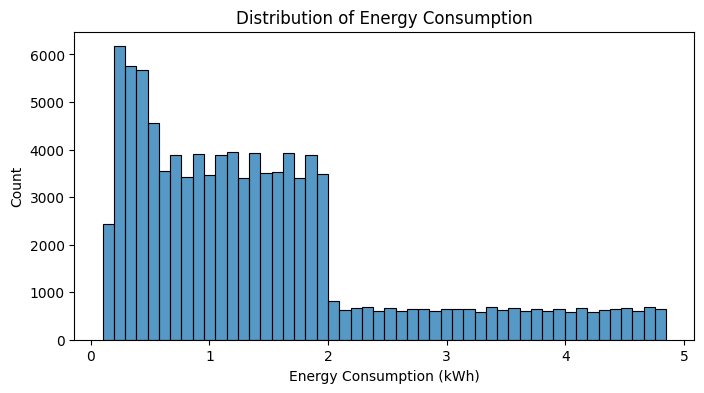

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(df['Energy Consumption (kWh)'], bins=50)
plt.title("Distribution of Energy Consumption")
plt.xlabel("Energy Consumption (kWh)")
plt.show()


In [ ]:
hourly_df = (
    df
    .groupby('Appliance Type')
    .resample('H')['Energy Consumption (kWh)']
    .sum()
    .reset_index()
)

hourly_df.head()


/tmp/ipython-input-1364392830.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample('H')['Energy Consumption (kWh)']


,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01 00:00:00,4.42
1,Air Conditioning,2023-01-01 01:00:00,7.61
2,Air Conditioning,2023-01-01 02:00:00,14.80
3,Air Conditioning,2023-01-01 03:00:00,4.19
4,Air Conditioning,2023-01-01 04:00:00,10.68


In [ ]:
hourly_df.shape


(87828, 3)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

hourly_df['Energy_Scaled'] = scaler.fit_transform(
    hourly_df[['Energy Consumption (kWh)']]
)

hourly_df[['Energy Consumption (kWh)', 'Energy_Scaled']].head()


,Energy Consumption (kWh),Energy_Scaled
0,4.42,0.179456
17567,3.31,0.134389
79046,1.12,0.045473
26351,0.80,0.032481
52699,1.68,0.068210


In [ ]:
daily_df = (
    df
    .groupby('Appliance Type')
    .resample('D')['Energy Consumption (kWh)']
    .sum()
    .reset_index()
)

daily_df.head()


,Appliance Type,timestamp,Energy Consumption (kWh)
0,Air Conditioning,2023-01-01,103.32
1,Air Conditioning,2023-01-02,91.14
2,Air Conditioning,2023-01-03,94.01
3,Air Conditioning,2023-01-04,105.96
4,Air Conditioning,2023-01-05,80.09


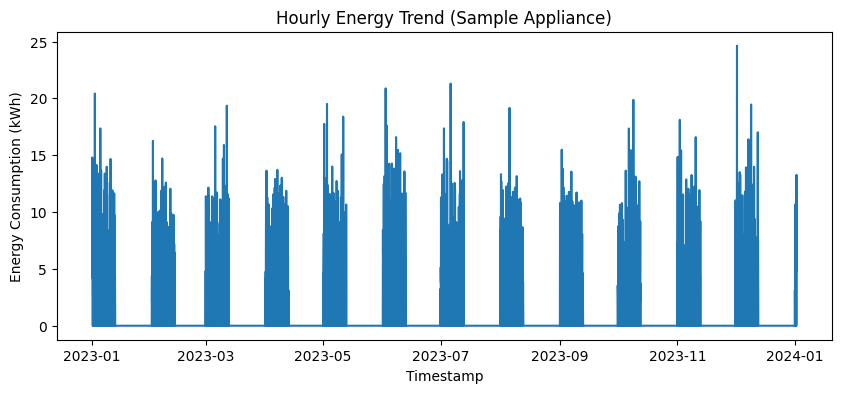

In [ ]:
sample_appliance = hourly_df['Appliance Type'].iloc[0]

plt.figure(figsize=(10,4))
sns.lineplot(
    data=hourly_df[hourly_df['Appliance Type'] == sample_appliance],
    x='timestamp',
    y='Energy Consumption (kWh)'
)
plt.title("Hourly Energy Trend (Sample Appliance)")
plt.xlabel("Timestamp")
plt.ylabel("Energy Consumption (kWh)")
plt.show()


In [ ]:

hourly_df = hourly_df.sort_values('timestamp')


train_size = int(len(hourly_df) * 0.7)
val_size = int(len(hourly_df) * 0.15)

train_df = hourly_df.iloc[:train_size]
val_df = hourly_df.iloc[train_size:train_size + val_size]
test_df = hourly_df.iloc[train_size + val_size:]

print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)
print("Test size:", test_df.shape)


Train size: (61479, 4)
Validation size: (13174, 4)
Test size: (13175, 4)
